In [327]:
from dustmaps.config import config
import dustmaps.edenhofer2023
import healpy as hp
import astropy as ap
from astropy.coordinates import SkyCoord
from dustmaps.edenhofer2023 import Edenhofer2023Query
import astropy.units as u
import numpy as np
import jax
import jax.numpy as jnp
import jax.random as jr
import matplotlib.pyplot as plt
from astropy.io import fits
from Better_HMC import HMCSampler 
import jax.scipy.special as jss
import arviz as az
with fits.open("mean_and_std_healpix.fits") as hdul:
    hdul.info()
    print(hdul['MEAN'].header['ORDERING'])
    print(hdul['STD.'].header['ORDERING'])
    galactic_center_healpix = hp.pixelfunc.ang2pix(256, theta = 0.0, phi = 0.0, nest = True, lonlat = True)
    mean_along_center = jnp.asarray(hdul["MEAN"].data[:, galactic_center_healpix].astype(np.float32))
    std_along_center  = jnp.asarray(hdul["STD."].data[:, galactic_center_healpix].astype(np.float32))
    radial_centers    = jnp.asarray(hdul["RADIAL PIXEL CENTERS"].data.field(0),    dtype=jnp.float32)
    radial_boundaries = jnp.asarray(hdul["RADIAL PIXEL BOUNDARIES"].data.field(0), dtype=jnp.float32)
    distance_gaps = np.diff(radial_boundaries)


assert mean_along_center.shape == distance_gaps.shape
    

Filename: mean_and_std_healpix.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU       9   ()      
  1  MEAN          1 ImageHDU        19   (786432, 516)   float32   
  2  STD.          1 ImageHDU        19   (786432, 516)   float32   
  3  RADIAL PIXEL CENTERS    1 BinTableHDU     20   516R x 1C   [E]   
  4  RADIAL PIXEL BOUNDARIES    1 BinTableHDU     20   517R x 1C   [E]   
  5  MEAN OF INTEGRATED INNER 68.8 PC    1 ImageHDU        16   (786432,)   float32   
  6  STD. OF INTEGRATED INNER 68.8 PC    1 ImageHDU        16   (786432,)   float32   
NEST
NEST


250
Slope of best fit line is -1.9504634141921997
Nu is 0.47523170709609985


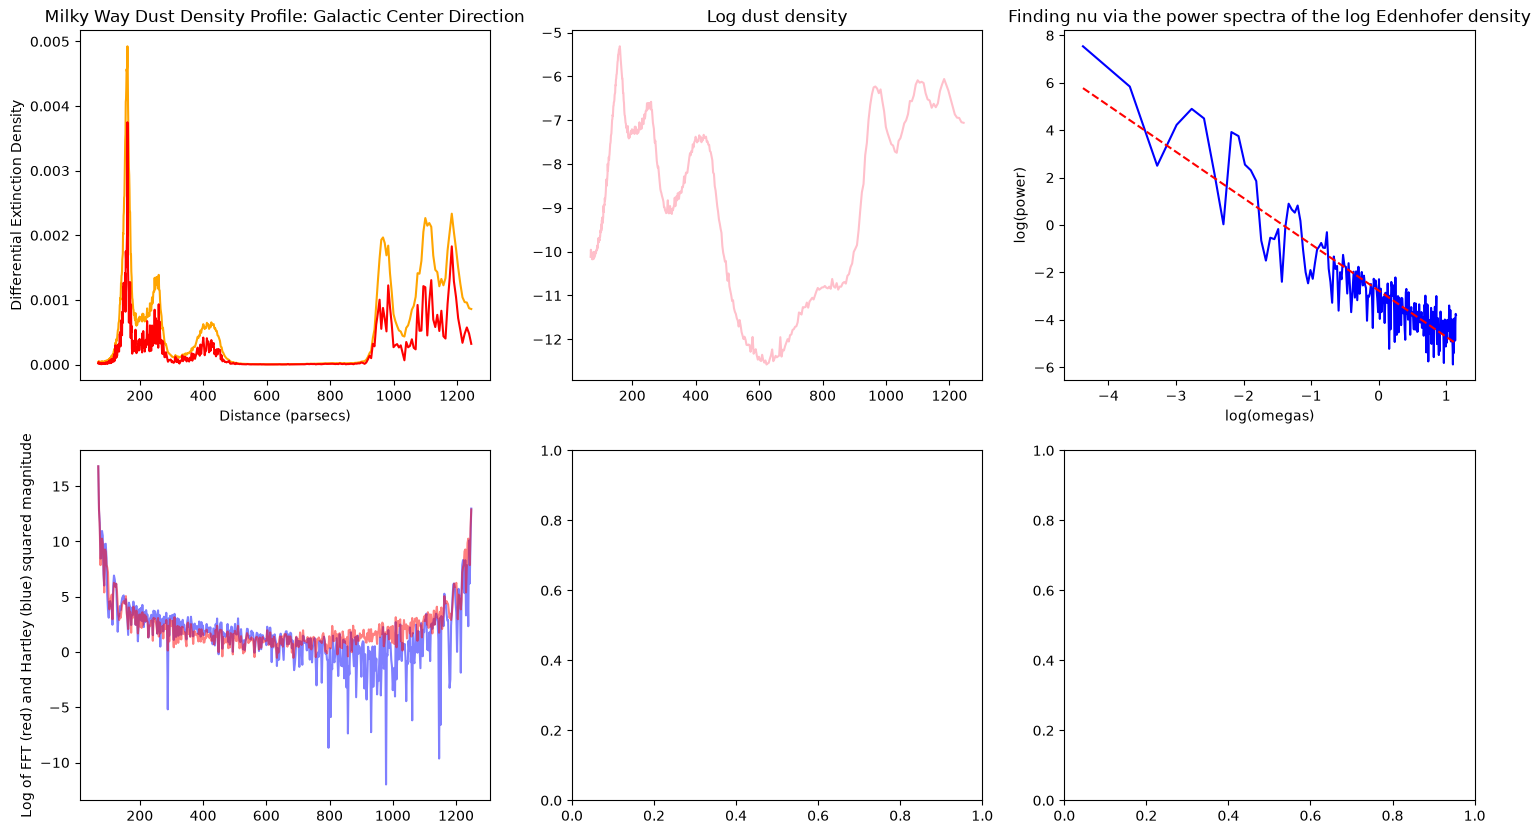

Number of centers 516 Number of boundaries 517
Min gap: 0.3868408203125 Max gap: 6.9967041015625
Min distance: 68.61872863769531 Max distance: 1248.10009765625


In [328]:
num_dimensions = 500
num_fourier_dimensions = 700
min_distance = radial_boundaries[0] 
max_distance = radial_boundaries[radial_boundaries.size - 1]
dx = (max_distance - min_distance)/(num_dimensions - 1)
dust_x_linspace = jnp.arange(num_dimensions)*dx + min_distance
interp_field = jnp.interp(dust_x_linspace, radial_centers, jnp.log(mean_along_center))
fourier_length = dx*(num_fourier_dimensions - 1)
def fold_spectrum(X):
    N = X.shape[0]
    m = N // 2 + 1
    full_fold = ((X + jnp.roll(X[::-1], 1)) / 2)[:m]
    return full_fold[1:]


def get_spectrum(field):
    omegas_condensed = 2*jnp.pi*jnp.fft.fftfreq(num_dimensions)
    spectra_with_noise = hartley(field)*jnp.sqrt(max_distance - min_distance)/num_dimensions
    log_spectrum = jnp.log(fold_spectrum(spectra_with_noise**2))
    print(log_spectrum.size)
    log_omegas = jnp.log(fold_spectrum(jnp.abs(omegas_condensed)))
    slope, intercept = jnp.polyfit(log_omegas, log_spectrum, 1)
    return log_omegas, log_spectrum, slope, intercept

def get_spectrum2(field):
    omegas_condensed = 2*jnp.pi*jnp.fft.fftfreq(num_dimensions)
    spectra_with_noise = jnp.fft.fft(field)
    log_spectrum = jnp.log(fold_spectrum(jnp.abs(spectra_with_noise)**2))
    log_omegas = jnp.log(fold_spectrum(jnp.abs(omegas_condensed)))
    slope, intercept = jnp.polyfit(log_omegas, log_spectrum, 1)
    return log_omegas, log_spectrum, slope, intercept

def hartley(x):
    fft = jnp.fft.fft(x)
    return jnp.real(fft) - jnp.imag(fft)

normalization_factor = num_fourier_dimensions/jnp.sqrt(fourier_length)


log_omegas, log_spectrum, slope, intercept = get_spectrum(interp_field)

print(f"Slope of best fit line is {slope}")
print(f"Nu is {(-1 - slope)/2}")
fig, axes = plt.subplots(2, 3, figsize = (18, 10))

axes[0][0].plot(radial_centers, mean_along_center, label = "dust density along line through galactic center", alpha = 1, color = "orange")
axes[0][0].plot(radial_centers, std_along_center, label = "standard deviation dust density along line through galactic center", alpha = 1, color = "red")
axes[0][0].set_title("Milky Way Dust Density Profile: Galactic Center Direction")
axes[0][0].set_xlabel("Distance (parsecs)")
axes[0][0].set_ylabel("Differential Extinction Density")
axes[0][1].plot(radial_centers, jnp.log(mean_along_center), color = "pink")
axes[0][1].set_title("Log dust density")
axes[0][2].plot(log_omegas, log_spectrum, color = "Blue")
arr = np.array([log_omegas.min(), log_omegas.max()])   # two points span the line
axes[0][2].plot(arr, slope * arr + intercept, color="red", linestyle="--", label="fit")
axes[0][2].set_xlabel("log(omegas)")
axes[0][2].set_ylabel("log(power)")
axes[0][2].set_title("Finding nu via the power spectra of the log Edenhofer density")
axes[1][0].plot(dust_x_linspace, jnp.log(hartley(interp_field)**2), color = "blue", alpha = 0.5)
axes[1][0].plot(dust_x_linspace, jnp.log(jnp.abs(jnp.fft.fft(interp_field))**2), color = "red", alpha = 0.5)
axes[1][0].set_ylabel("Log of FFT (red) and Hartley (blue) squared magnitude")
plt.show()



print(f"Number of centers {radial_centers.size} Number of boundaries {radial_boundaries.size}")
print(f"Min gap: {distance_gaps[0]} Max gap: {distance_gaps[distance_gaps.size - 1]}")

print(f"Min distance: {min_distance} Max distance: {max_distance}")

# Always set fourier_min_distance to min_distance so that when converting the entire field to the field that matters we can just truncate the right portion of it


In [329]:
num_fitting_params = 3
num_data = radial_boundaries.size
omegas = 2*jnp.pi*jnp.fft.fftfreq(num_fourier_dimensions, d = dx)

error_bars_on_data = 0.025

rng = jr.PRNGKey(0)
rng, key = jr.split(rng)


num_overall_steps = 220
burn_in = 10
num_integration_steps = 2000
step_size = 0.0005

initial_logvar = 4.0
initial_lognu = 0
initial_offset = -7.5

logvar_prior_mean = initial_logvar
lognu_prior_mean = 0.0
offset_prior_mean = initial_offset

#prior_mean_position = jnp.zeros(num_fourier_dimensions).at[0].set(-4)


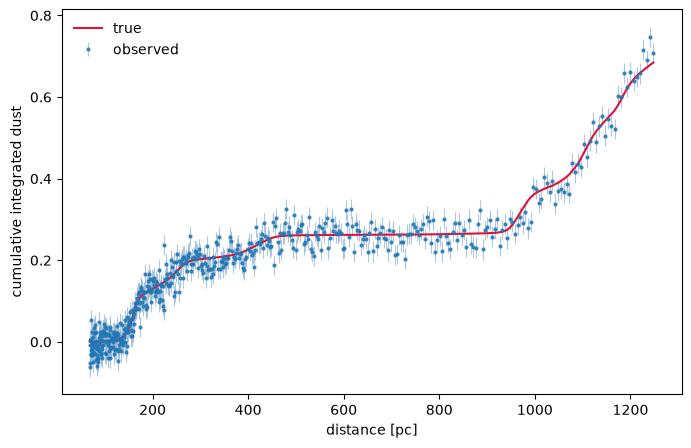

In [330]:
cumulative_integrated_dust = jnp.concatenate(
    [jnp.array([0.0]), jnp.cumsum(mean_along_center * distance_gaps)]
)
x_obs = radial_boundaries
y_obs_true = cumulative_integrated_dust
yerr = jnp.ones(shape = (radial_boundaries.size, ))*error_bars_on_data
y_obs_err = yerr*jr.normal(key, shape = (radial_boundaries.size, ))
y_obs = y_obs_true + y_obs_err

inv_cov_data_matrix = jnp.linalg.inv(jnp.diag(yerr**2))


fig, ax = plt.subplots(figsize=(8, 5))
ax.errorbar(
    x_obs, y_obs,
    yerr=jnp.abs(yerr),      
    fmt='.', markersize=4,
    ecolor='#9ab8d8', elinewidth=0.8, capsize=0, alpha=0.8,
    label='observed',
)
ax.plot(x_obs, y_obs_true, color='crimson', lw=1.5, label='true')
#ax.set_xscale('log')             # optional, but natural for log-spaced radial_centers
ax.set_xlabel('distance [pc]')
ax.set_ylabel('cumulative integrated dust')
ax.legend(frameon=False)
plt.show()

In [331]:
fixed_logscale = jnp.log(2*fourier_length)


def cumulative_trapezoid(y, dx):
    seg = dx * (y[:-1] + y[1:]) / 2.0            # area of each trapezoid segment
    return jnp.concatenate([jnp.zeros(1, y.dtype), jnp.cumsum(seg)])


# Each element in this array is the 
def exponentiated_integrated_density(logdensity):
    density = jnp.exp(logdensity)
    return cumulative_trapezoid(density, dx)

def response_function(xi, inference_params, offset):
    field = fft_field_hartley(xi, inference_params) + offset
    exp_int_field = exponentiated_integrated_density(field)
    return jnp.interp(x_obs, dust_x_linspace, exp_int_field)


def general_matern_spectral_density(omega, inference_params, jitter = 1e-6):
        logvar, lognu = inference_params
        #logvar, lognu = 5.0, jnp.log(0.475)
        logscale = fixed_logscale
        nu = jnp.exp(lognu)
        log_ratio = jss.gammaln(nu + 0.5) - jss.gammaln(nu)
        r = jnp.square(omega) * jnp.exp(2 * logscale - jnp.log(2.0) - lognu)
        logdensity = logvar + log_ratio - 0.5*jnp.log(2*nu) + logscale - (nu + 0.5)*jnp.log1p(r)
        result = 2*jnp.sqrt(jnp.pi)*jnp.exp(logdensity)
        return jnp.where(omega > 0, result, result * (1.0 + jitter))

def matern_magnitude(omegas, inference_params):
     return jnp.sqrt(general_matern_spectral_density(omegas, inference_params))


def fft_field_hartley(noise, inference_params):
    size = noise.shape[0]
    raw_average_amplitude_data = matern_magnitude(omegas, inference_params)
    H = noise * raw_average_amplitude_data          # elementwise, whole array, in order
    y_data = (hartley(H) / size) * normalization_factor 
    return y_data[0:num_dimensions]

Text(0.5, 1.0, 'Diagonal Covariance')

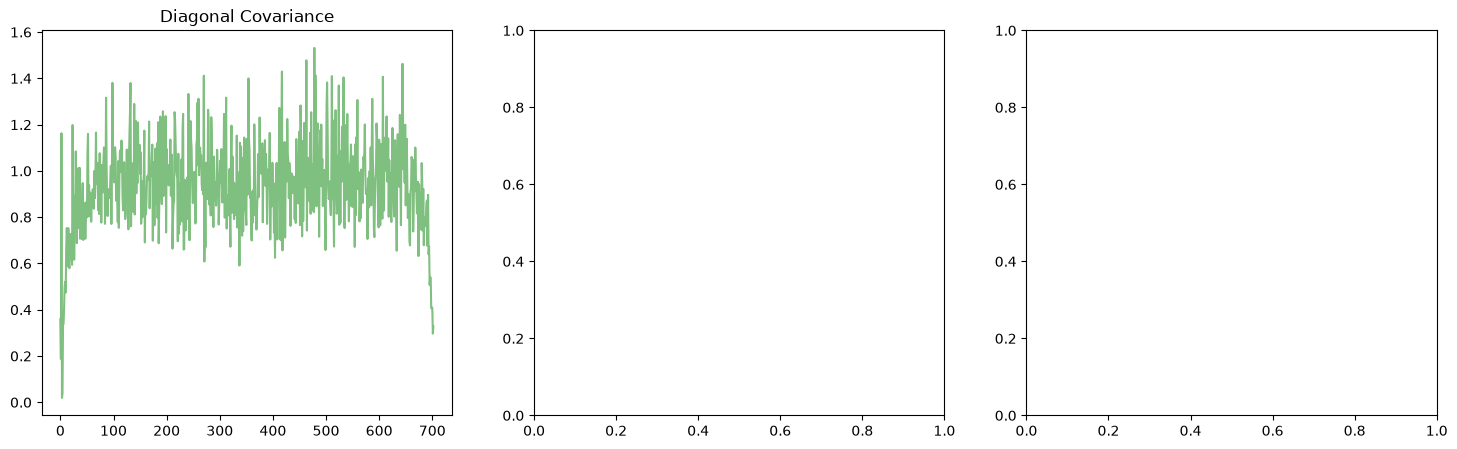

In [332]:
def logvarprior(logvar):
    return -0.5*(logvar - logvar_prior_mean)**2
def lognuprior(lognu):
    return -0.5*(lognu - lognu_prior_mean)**2
def logoffsetprior(offset):
    return -0.5*(offset - offset_prior_mean)**2
def negative_logdensity(x):
    logvar = x[0]
    lognu = x[1]
    offset = x[2]
    xi = x[3:]
    inference_params = (logvar, lognu)
    negative_log_p_s = -logvarprior(logvar) - lognuprior(lognu) - logoffsetprior(offset) + 0.5*xi.T @ xi
    res = y_obs - response_function(xi, inference_params, offset)
    negative_log_p_d_given_s = 0.5*res.T @ inv_cov_data_matrix @ res
    return negative_log_p_s + negative_log_p_d_given_s

initial_coordinates = jnp.zeros(num_fourier_dimensions + num_fitting_params) 
initial_coordinates = initial_coordinates.at[0].set(initial_logvar)
initial_coordinates = initial_coordinates.at[1].set(initial_lognu)
initial_coordinates = initial_coordinates.at[2].set(initial_offset)
num_good_samples = num_overall_steps - burn_in
time_arr = jnp.arange(num_good_samples)

sampler = HMCSampler(
    negative_logdensity= negative_logdensity,
    num_integration_steps=num_integration_steps,
    step_size=step_size,
    inv_mass_matrix = jnp.eye(num_fourier_dimensions + num_fitting_params),
    #inv_mass_matrix = updated_inv_mass_matrix,
    alpha=1.0
)

rng = jr.PRNGKey(5)

overall_data_arr, overall_momentum_arr, accept_prob_arr = sampler.sample(
    start_position=initial_coordinates, 
    num_samples=num_overall_steps,
    burn_in = burn_in,
    rng_key=rng
)

logvars = overall_data_arr[:, 0]
lognus = overall_data_arr[:, 1]
offsets = overall_data_arr[:, 2]
overall_position_arr = overall_data_arr[:, 3:]  
logscales = jnp.zeros_like(logvars)
inference_params = (logvars, lognus)

overall_position_arr_raw = jax.vmap(fft_field_hartley, in_axes=(0, 0))(
    overall_position_arr, inference_params
) 
overall_position_arr_raw = overall_position_arr_raw + offsets[:, None]
overall_position_arr_exp = jax.vmap(exponentiated_integrated_density, in_axes=(0))(
    overall_position_arr_raw
)
overall_position_arr_raw = overall_position_arr_raw[:, 0:num_dimensions]
overall_position_arr_exp = overall_position_arr_exp[:, 0:num_dimensions]

mean_position_raw = overall_position_arr_raw.sum(axis=0)/num_good_samples
mean_position_exp = overall_position_arr_exp.sum(axis=0)/num_good_samples
vars = jnp.exp(logvars)
scales = jnp.exp(logscales)
nus = jnp.exp(lognus)
cov= jnp.cov(overall_data_arr, rowvar = False)
fig, axes = plt.subplots(1, 3, figsize = (18, 5))
timegrid = jnp.arange(num_fourier_dimensions + num_fitting_params)
axes[0].plot(timegrid, jnp.diagonal(cov), color = "Green", alpha = 0.5)
axes[0].set_title("Diagonal Covariance")
#np.save('cov_matrix_exp_int_fitting_variance_nu_matern.npy', np.asarray(cov))



ESS for Variance parameter (index 0): 43.64924296735483
ESS for Nu parameter (index 1): 54.77402894164818
ESS for 29th parameter (index 30): 25.294889197119574
Num integration steps: 2000 Step Size: 0.0005
Average acceptance probability (acceptance rate) is: 0.7721589803695679
Num dimensions: 500 Num data: 517 Total length: 1179.4813232421875 Noise on each point: 0.025 Num HMC trials: 220
(210, 500)
Error bars on data: 0.025
Logvar prior mean: 4.0 Lognu prior mean: 0.0 Offset prior mean -7.5 Initial logvar/lognu/offset values: 4.0, 0, -7.5
Average chi_2 statistic based on the prior: 0.9407824277877808
Average chi_2 statistic based on the data per data point: 1.061855435371399


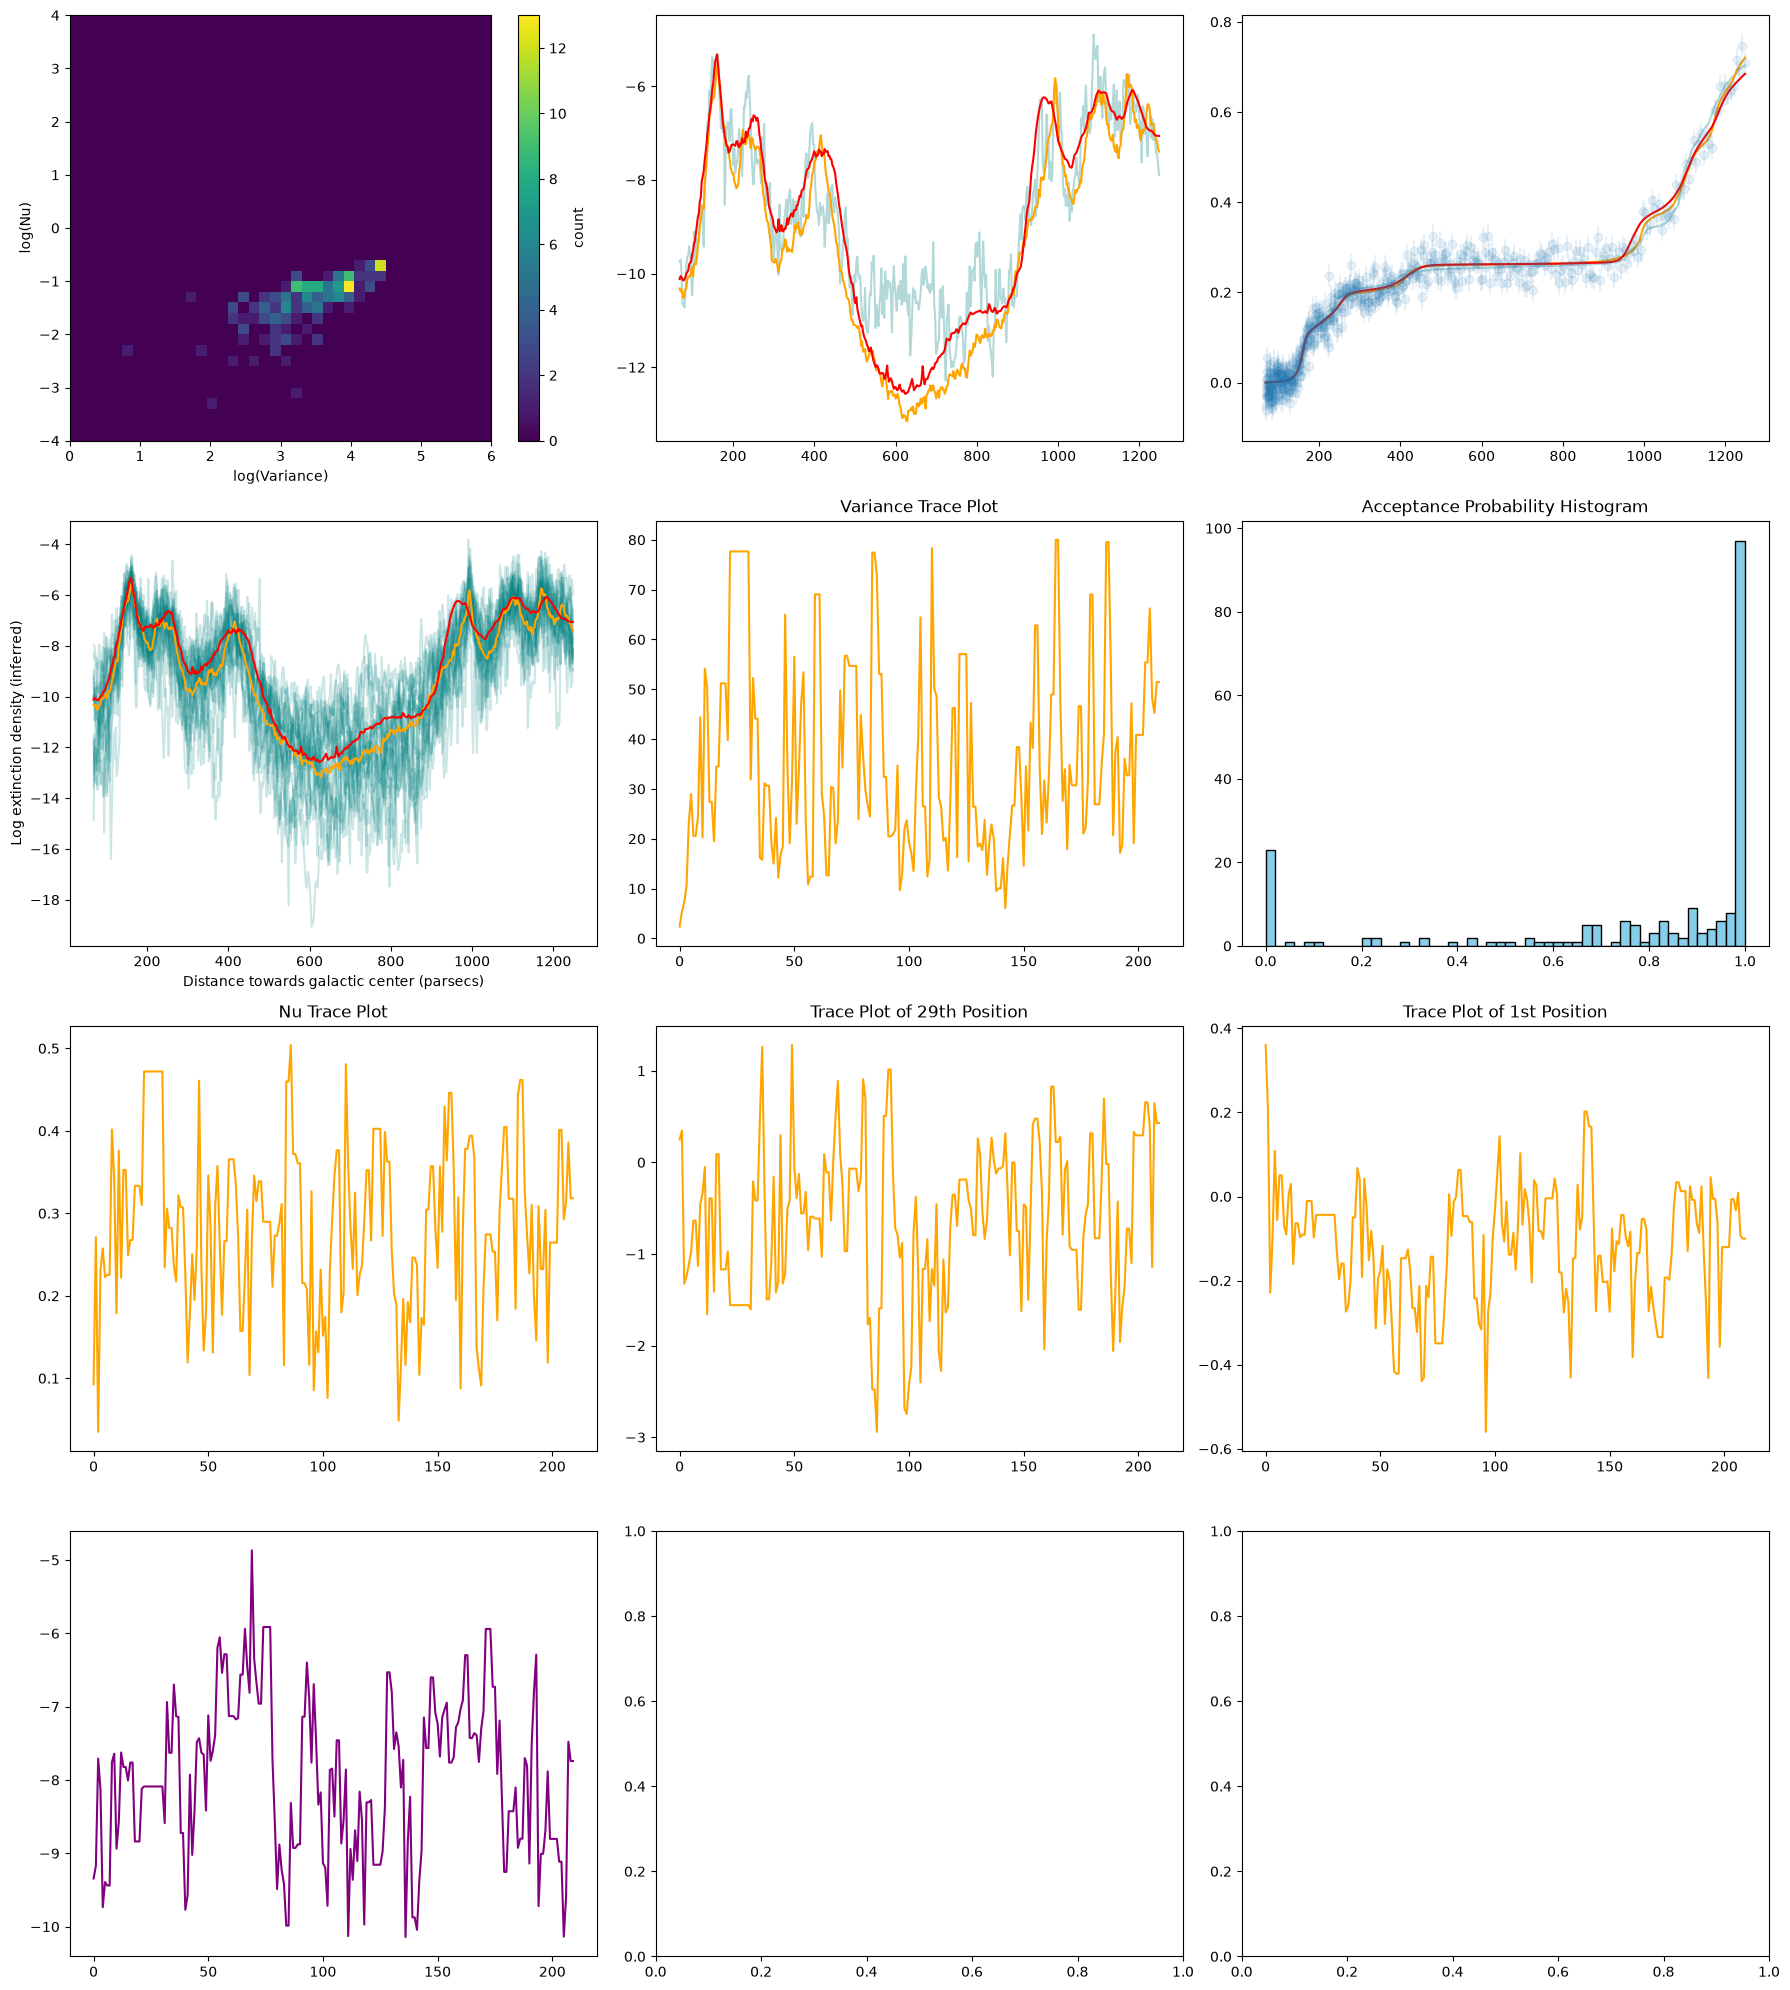

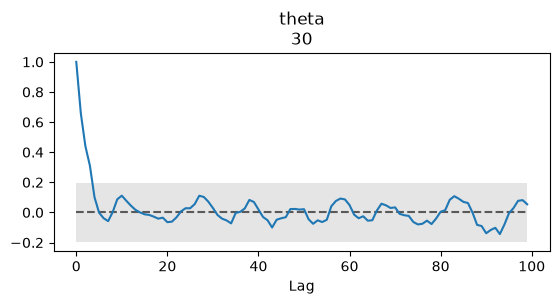

In [333]:
fig, axes = plt.subplots(4, 3, figsize = (18, 20))
for i in range (0, 1):
    axes[0][2].plot(dust_x_linspace, overall_position_arr_exp[500*i, :], color = "teal", alpha = 0.3)
    axes[0][1].plot(dust_x_linspace, overall_position_arr_raw[500*i, :], color = "teal", alpha = 0.3)





# rows you're actually plotting
indices = np.array([10*i for i in range(20)])
mask_indices = np.where(lognus > 0)[0]         
#indices = np.concatenate([indices, mask_indices])


# apply F to every plotted row at once, then bring to host as numpy
values = np.asarray(jax.vmap(negative_logdensity)(overall_data_arr[indices, :]))   # shape (n_lines,)

# colormap + normalization over the full value range
cmap = plt.cm.viridis
norm = plt.Normalize(vmin=values.min(), vmax=values.max())

for k, i in enumerate(range(indices.size)):
    axes[1][0].plot(
        dust_x_linspace,
        overall_position_arr_raw[indices[i], :],
        color = "teal",
        #color=cmap(norm(values[k])),
        alpha=0.2,
    )

sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
#cbar = fig.colorbar(sm, ax=axes[1][0])
#cbar.set_label("Negative logdensity")   

axes[1][0].set_ylabel("Log extinction density (inferred)")
axes[1][0].set_xlabel("Distance towards galactic center (parsecs)")


axes[0][1].plot(dust_x_linspace, mean_position_raw, color = "orange", alpha = 1)
axes[1][0].plot(dust_x_linspace, mean_position_raw, color = "orange", alpha = 1)
axes[0][1].plot(dust_x_linspace, jnp.interp(dust_x_linspace, radial_centers, jnp.log(mean_along_center)), color = "red", alpha = 1)
axes[1][0].plot(dust_x_linspace, jnp.interp(dust_x_linspace, radial_centers, jnp.log(mean_along_center)), color = "red", alpha = 1)
axes[0][2].plot(dust_x_linspace, mean_position_exp, color = "orange", alpha = 1)
axes[0][2].plot(dust_x_linspace, jnp.interp(dust_x_linspace, radial_boundaries, cumulative_integrated_dust), color = "red", alpha = 1)
axes[0][2].errorbar(x_obs, y_obs, yerr=yerr, fmt='o', label='Observations', alpha = 0.1)


number_bins_x = 40
number_bins_y = 40
x_min, x_max = -0, 6
y_min, y_max = -4, 4
dx = (x_max - x_min)/number_bins_x
dy = (y_max - y_min)/number_bins_y

x_centers = (jnp.arange(number_bins_x) + 0.5)*dx + x_min
y_centers = (jnp.arange(number_bins_y) + 0.5)*dy + y_min
x_edges = jnp.arange(number_bins_x + 1)*dx + x_min
y_edges = jnp.arange(number_bins_y + 1)*dy + y_min

H_HMC_samples, _, _ = jnp.histogram2d(logvars, lognus, bins=[x_edges, y_edges])

im2 = axes[0][0].imshow(
    H_HMC_samples.T,
    origin='lower',
    extent=[x_min, x_max, y_min, y_max],
    aspect='auto',
    cmap='viridis',
)
fig.colorbar(im2, ax=axes[0][0], label='count')

axes[0][0].set_xlabel("log(Variance)")
axes[0][0].set_ylabel("log(Nu)")
axes[1][1].plot(time_arr, vars, color = "Orange")
axes[1][1].set_title("Variance Trace Plot")
axes[2][0].plot(time_arr, nus, color = "Orange")
axes[2][0].set_title("Nu Trace Plot")
axes[2][1].plot(time_arr, overall_position_arr[:, 28], color = "Orange")
axes[2][1].set_title("Trace Plot of 29th Position")
axes[2][2].plot(time_arr, overall_position_arr[:, 0], color = "Orange")
axes[2][2].set_title("Trace Plot of 1st Position")
axes[1][2].set_title("Acceptance Probability Histogram")
axes[1][2].hist(accept_prob_arr, bins=50, edgecolor='black', color='skyblue')

axes[3][0].plot(time_arr, offsets, color = "Purple")

fig.tight_layout()


posterior_samples = overall_data_arr[np.newaxis, :, :]  # add chain axis -> (1, num_samples, 50)

idata = az.from_dict({"posterior": {"theta": posterior_samples}})

param_index = 30  # first parameter (0-indexed)

az.plot_autocorr(idata, var_names="theta", coords={"theta_dim_0": [param_index]})

ess_all = az.ess(idata, var_names="theta")  # a Dataset, ESS for all 50 parameters at once

# Indices of interest: "first", "second", and "32nd" parameter, 0-indexed as 0, 1, 31
indices_of_interest = {
    "Variance": 0,
    "Nu": 1,
    "29th": 30,
}

for label, idx in indices_of_interest.items():
    ess_val = ess_all["theta"].sel(theta_dim_0=idx).values
    print(f"ESS for {label} parameter (index {idx}): {ess_val}")

def KL_divergence(expected_probs, observed_probs, jitter):
    usable_expected_probs = jnp.where(expected_probs == 0, jitter, expected_probs)
    usable_observed_probs = jnp.where(observed_probs == 0, jitter, observed_probs)
    KL_array = usable_expected_probs*(jnp.log(usable_expected_probs) - jnp.log(usable_observed_probs))
    return jnp.sum(KL_array)
print(f"Num integration steps: {num_integration_steps} Step Size: {step_size}")
print(f"Average acceptance probability (acceptance rate) is: {jnp.average(accept_prob_arr)}")
print(f"Num dimensions: {num_dimensions} Num data: {num_data} Total length: {max_distance - min_distance} Noise on each point: {error_bars_on_data} Num HMC trials: {num_overall_steps}")

print(overall_position_arr_raw.shape)


def average_chi_2_based_on_data(x_data, x_field, data, field, inverse_data_cov):
    interp_all_rows = jax.vmap(lambda row: jnp.interp(x_data, x_field, row))
    raw_field_at_data_points = interp_all_rows(field)
    residuals = raw_field_at_data_points - data
    chi_2 = jnp.einsum('ij,jk,ik->i', residuals, inverse_data_cov, residuals)
    return jnp.average(chi_2)/data.size

prior_variances = jnp.diag(cov)[2:]
print(f"Error bars on data: {error_bars_on_data}")
print(f"Logvar prior mean: {logvar_prior_mean} Lognu prior mean: {lognu_prior_mean} Offset prior mean {offset_prior_mean} Initial logvar/lognu/offset values: {initial_logvar}, {initial_lognu}, {initial_offset}")
print(f"Average chi_2 statistic based on the prior: {jnp.average(prior_variances)}")
print(f"Average chi_2 statistic based on the data per data point: {average_chi_2_based_on_data(x_obs, dust_x_linspace, y_obs, overall_position_arr_exp, inv_cov_data_matrix)}")